In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Libraries loaded and seed fixed")

Libraries loaded and seed fixed


In [2]:
# Load training data
train_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)

# Load testing data
test_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)


print("Training data shape:", train_data.shape)
print("Testing data shape :", test_data.shape)

Training data shape: (1948553, 41)
Testing data shape : (487139, 41)


In [3]:
# Features
X_train = train_data.drop(
    "label",
    axis=1
)

X_test = test_data.drop(
    "label",
    axis=1
)


# Labels
y_train = train_data["label"]

y_test = test_data["label"]


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1948553, 40)
X_test : (487139, 40)
y_train: (1948553,)
y_test : (487139,)


In [4]:
rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=None,

    min_samples_split=2,

    random_state=SEED,

    n_jobs=-1,

    class_weight="balanced"

)


print("Random Forest created")

Random Forest created


In [5]:
rf_model.fit(
    X_train,
    y_train
)

y_pred = rf_model.predict(
    X_test
)

In [6]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9978466105156845
Precision: 0.9988277580353045
Recall   : 0.9978466105156845
F1 Score : 0.9982036864983583


In [7]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9999    0.9974    0.9987    357145
           1     1.0000    1.0000    1.0000      1102
           2     0.9999    1.0000    0.9999     19147
           3     0.9911    0.9970    0.9940      1673
           4     0.9999    0.9999    0.9999     69479
           5     0.9870    0.9934    0.9902      1372
           6     0.9809    0.9923    0.9866      1035
           7     1.0000    1.0000    1.0000      1906
           8     0.0000    0.0000    0.0000         2
           9     0.9996    0.9999    0.9998     32265
          10     0.9983    1.0000    0.9992      1190
          11     0.4380    0.8720    0.5831       547
          12     1.0000    0.8000    0.8889         5
          13     0.4391    0.9446    0.5995       271

    accuracy                         0.9978    487139
   macro avg     0.8453    0.8998    0.8600    487139
weighted avg     0.9988    0.9978    0.9982    487139



c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

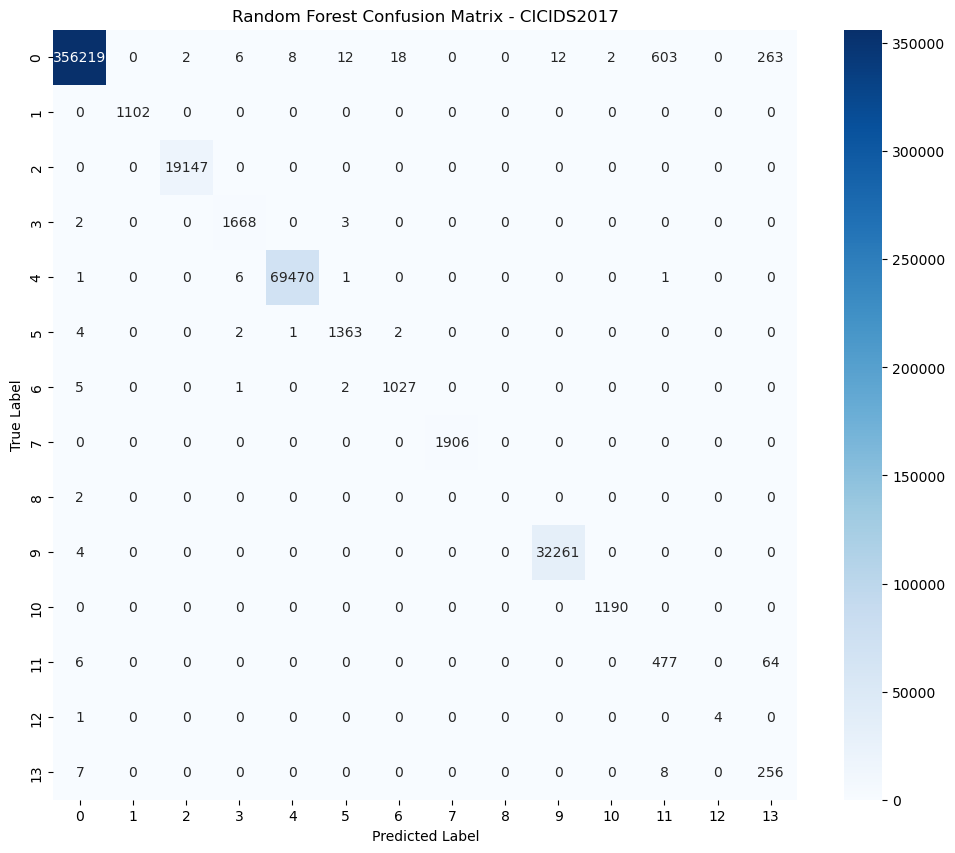

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(12,10)
)


sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "Random Forest Confusion Matrix - CICIDS2017"
)


plt.show()

In [9]:
joblib.dump(
    rf_model,
    "RandomForest_CICIDS2017.pkl"
)


print("Random Forest model saved")

Random Forest model saved


In [10]:
rf_results = pd.DataFrame({

    "Model": [
        "Random Forest"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1_Score": [
        f1
    ],

   

})


rf_results.to_csv(
    "RandomForest_results.csv",
    index=False
)


print(rf_results)

           Model  Accuracy  Precision    Recall  F1_Score
0  Random Forest  0.997847   0.998828  0.997847  0.998204


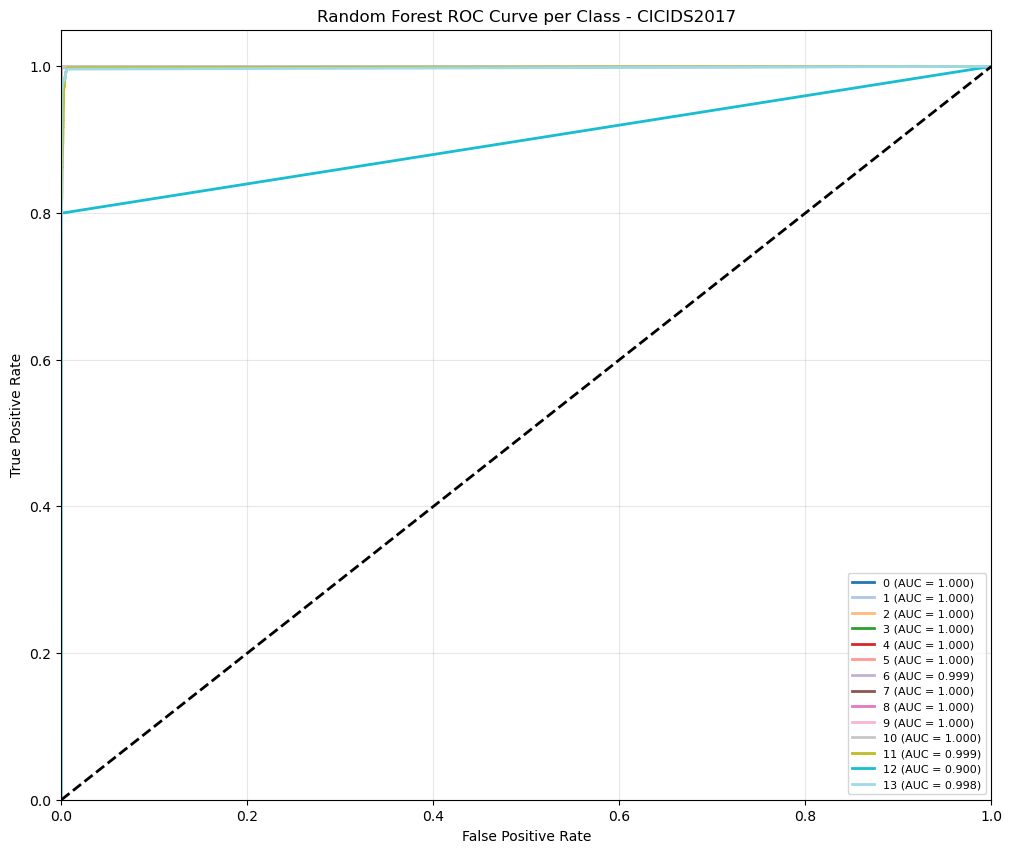

In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities
y_score = rf_model.predict_proba(X_test)

# Get all classes
classes = rf_model.classes_

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=classes)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(12, 10))

colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))

for i, color in zip(range(len(classes)), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve per Class - CICIDS2017")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

plt.show()